# PHQ-8 Depression Detection — WavLM + LSTM + Attention Pooling + MLP (Classification)

**Architecture**: Frozen WavLM (`microsoft/wavlm-base-plus`) → sequence of mean-pooled 768-dim segment features → **LSTM(768, 64)** → **Learned Attention Pooling** → 64-dim participant vector → `MLP(64→64→1)` → binary logit.

**Task**: Binary classification — depressed (PHQ-8 ≥ 10) vs. control (PHQ-8 < 10).

**Why WavLM over HuBERT**:
- WavLM is pretrained with a masked speech prediction objective that also denoises corrupted speech, making it more robust to real-world acoustic conditions.
- `wavlm-base-plus` is pretrained on a much larger and more diverse corpus (LibriSpeech + VoxPopuli + CommonVoice + GigaSpeech) vs HuBERT's LibriSpeech-only training.
- WavLM consistently outperforms HuBERT on speaker and paralinguistic tasks — depression detection is a paralinguistic task.

**Features**: Extracted and cached to `processed/wavlm_features_cls.npz` on first run.

**Input**: Sequence of 768-dim WavLM features, one per 8-second window (4-second hop, 50% overlap).

**Target**: Binary label — 0 (control) or 1 (depressed).

## 1. Install Dependencies

In [1]:
!pip install transformers librosa tqdm pandas numpy scikit-learn --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [2]:
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports successful.")

Imports successful.


In [ ]:
# --- Reproducibility ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Global seed    : {SEED}")

# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"
if list(DATASET_DIR.glob("*_P.wav")):
    AUDIO_DIR = DATASET_DIR
elif list((PROCESSED_DIR / "isolated_audio").glob("*_P.wav")):
    AUDIO_DIR = PROCESSED_DIR / "isolated_audio"
else:
    raise FileNotFoundError("No *_P.wav files found in dataset/ or processed/isolated_audio/")


TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

FEATURE_CACHE = PROCESSED_DIR / "wavlm_features_cls.npz"

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "wavlm_lstm_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Global seed    : 42
Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\wavlm_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\wavlm_lstm_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs — 1 if PHQ-8 ≥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [4]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Audio files in `dataset/` are segmented into **8-second windows** with a **4-second (50%) hop**.
Each segment is passed through frozen WavLM and mean-pooled over the frame dimension → **768-dim feature vector**.

Features are saved to `processed/wavlm_features_cls.npz` and reloaded on subsequent runs.

In [ ]:
SR             = 16_000
WIN_SEC        = 8
HOP_SEC        = 4
WIN_SAMPLES    = WIN_SEC * SR
HOP_SAMPLES    = HOP_SEC * SR
WAVLM_MODEL_ID = str(Path("models") / "wavlm-base-plus")   # local model folder

AUGMENT_TRAIN = True
NOISE_PROB    = 0.8
NOISE_SNR_DB  = (15.0, 30.0)
SHIFT_PROB    = 0.5
MAX_SHIFT_SEC = 0.25

def augment_train_segment(seg: np.ndarray, sr: int = SR) -> np.ndarray:
    """Mild augmentation for training segments only.
    Keeps prosodic cues largely intact while improving robustness.
    """
    aug = seg.astype(np.float32, copy=True)

    if np.random.rand() < SHIFT_PROB:
        max_shift = int(MAX_SHIFT_SEC * sr)
        if max_shift > 0:
            shift = np.random.randint(-max_shift, max_shift + 1)
            aug = np.roll(aug, shift)
            if shift > 0:
                aug[:shift] = 0.0
            elif shift < 0:
                aug[shift:] = 0.0

    if np.random.rand() < NOISE_PROB:
        snr_db = np.random.uniform(*NOISE_SNR_DB)
        signal_power = np.mean(aug ** 2)
        if signal_power > 0:
            noise_power = signal_power / (10 ** (snr_db / 10.0))
            noise = np.random.normal(0.0, np.sqrt(noise_power), size=aug.shape).astype(np.float32)
            aug = aug + noise

    return np.clip(aug, -1.0, 1.0)

def extract_wavlm_feature(segment: np.ndarray, feat_extractor, wavlm) -> np.ndarray:
    inputs = feat_extractor(
        segment.tolist(), sampling_rate=SR, return_tensors="pt", padding=True
    )
    with torch.no_grad():
        hidden = wavlm(inputs.input_values.to(DEVICE)).last_hidden_state
    return hidden.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)


if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} — skipping extraction.")
else:
    print(f"Extracting WavLM features → {FEATURE_CACHE.name}")
    print(f"  Model  : {WAVLM_MODEL_ID}")
    print(f"  Window : {WIN_SEC}s   Hop : {HOP_SEC}s")
    print(f"  Train augmentation enabled : {AUGMENT_TRAIN} (one view sampled per segment per epoch)")

    from transformers import WavLMModel, AutoFeatureExtractor

    feat_extractor = AutoFeatureExtractor.from_pretrained(WAVLM_MODEL_ID)
    wavlm = WavLMModel.from_pretrained(WAVLM_MODEL_ID)
    wavlm.eval().to(DEVICE)
    for param in wavlm.parameters():
        param.requires_grad = False
    print(f"WavLM loaded and frozen.")

    all_orig_feats, all_aug_feats = [], []
    all_bin_labels, all_pids, all_splits, all_has_aug = [], [], [], []
    original_segment_count = 0
    augmented_segment_count = 0

    audio_files = sorted(AUDIO_DIR.glob("*_P.wav"))
    print(f"\nProcessing {len(audio_files)} audio files ...")

    for wav_path in tqdm(audio_files):
        pid = int(wav_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue

        split = pid_to_split[pid]
        label = pid_to_label[pid]

        audio, _ = librosa.load(str(wav_path), sr=SR, mono=True)

        # Sliding-window segmentation
        starts = list(range(0, len(audio) - WIN_SAMPLES + 1, HOP_SAMPLES))
        if not starts:           # audio shorter than one window — pad
            audio  = np.pad(audio, (0, WIN_SAMPLES - len(audio)))
            starts = [0]

        for start in starts:
            seg = audio[start : start + WIN_SAMPLES].astype(np.float32)

            orig_feat = extract_wavlm_feature(seg, feat_extractor, wavlm)
            if split == "train" and AUGMENT_TRAIN:
                aug_seg  = augment_train_segment(seg, sr=SR)
                aug_feat = extract_wavlm_feature(aug_seg, feat_extractor, wavlm)
                has_aug  = 1
                augmented_segment_count += 1
            else:
                aug_feat = orig_feat
                has_aug  = 0

            all_orig_feats.append(orig_feat)
            all_aug_feats.append(aug_feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())
            all_has_aug.append(has_aug)
            original_segment_count += 1

    np.savez_compressed(
        FEATURE_CACHE,
        orig_feats    = np.array(all_orig_feats,  dtype=np.float32),
        aug_feats     = np.array(all_aug_feats,   dtype=np.float32),
        binary_labels = np.array(all_bin_labels,  dtype=np.int32),
        pids          = np.array(all_pids,        dtype=np.int32),
        splits        = np.array(all_splits),
        has_aug       = np.array(all_has_aug,     dtype=np.int8),
    )
    print(f"\nSaved {len(all_orig_feats):,} segment feature pairs → {FEATURE_CACHE}")
    print(f"  Original segments       : {original_segment_count:,}")
    print(f"  Augmented train views   : {augmented_segment_count:,}")

    del wavlm, feat_extractor
    torch.cuda.empty_cache()


Extracting WavLM features → wavlm_features_cls.npz
  Model  : models\wavlm-base-plus
  Window : 8s   Hop : 4s
  Train augmentation enabled : True (one view sampled per segment per epoch)
WavLM loaded and frozen.

Processing 189 audio files ...


100%|██████████| 189/189 [20:59<00:00,  6.66s/it]



Saved 21,588 segment feature pairs → ..\processed\wavlm_features_cls.npz
  Original segments       : 21,588
  Augmented train views   : 11,362


## 5. Build Participant-Level Dataset

Load the cached features and group segments by participant.
The attention layer will learn to weight segments — no ordering assumption needed.

In [6]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_orig_feats_np = cache["orig_feats"]      # (N, 768)
all_aug_feats_np  = cache["aug_feats"]       # (N, 768)
all_labels_np     = cache["binary_labels"]   # (N,)
all_pids_np       = cache["pids"]            # (N,)
all_splits_np     = cache["splits"]          # (N,)  byte strings
all_has_aug_np    = cache["has_aug"]         # (N,)

in_memory = {
    "train": defaultdict(lambda: {"orig_feats": [], "aug_feats": [], "has_aug": [], "label": None}),
    "dev":   defaultdict(lambda: {"orig_feats": [], "aug_feats": [], "has_aug": [], "label": None}),
    "test":  defaultdict(lambda: {"orig_feats": [], "aug_feats": [], "has_aug": [], "label": None}),
}

for orig_feat, aug_feat, lbl, pid, split_b, has_aug in zip(
    all_orig_feats_np, all_aug_feats_np, all_labels_np, all_pids_np, all_splits_np, all_has_aug_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["orig_feats"].append(orig_feat)
    in_memory[split][pid]["aug_feats"].append(aug_feat)
    in_memory[split][pid]["has_aug"].append(int(has_aug))
    in_memory[split][pid]["label"] = int(lbl)

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Segments':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_segs = sum(len(d["orig_feats"]) for _, d in splits_list[s])
    n_dep  = sum(d["label"] for _, d in splits_list[s])
    n_ctrl = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_segs:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from wavlm_features_cls.npz ...

Split       Participants  Segments  Depressed  Control
----------------------------------------------------
train                107    11,362         30       77
validation            35     4,322         12       23
test                  47     5,904         14       33


## 6. Training Configuration

In [7]:
# --- Model hyper-parameters ---
WAVLM_DIM          = 768
LSTM_HIDDEN        = 64
LSTM_LAYERS        = 1
LSTM_BIDIRECTIONAL = False
MLP_HIDDEN         = 64
DROPOUT            = 0.5

LSTM_OUT_DIM = LSTM_HIDDEN * (2 if LSTM_BIDIRECTIONAL else 1)

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 1000
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 100
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

print("Training configuration:")
print(f"  WavLM feature dim      : {WAVLM_DIM}")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN}")
print(f"  LSTM layers            : {LSTM_LAYERS}")
print(f"  LSTM bidirectional     : {LSTM_BIDIRECTIONAL}")
print(f"  LSTM output dim        : {LSTM_OUT_DIM}")
print(f"  MLP hidden dim         : {MLP_HIDDEN}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration:
  WavLM feature dim      : 768
  LSTM hidden dim        : 64
  LSTM layers            : 1
  LSTM bidirectional     : False
  LSTM output dim        : 64
  MLP hidden dim         : 64
  Dropout                : 0.5
  Participant batch size : 16
  Epochs                 : 1000
  Learning rate          : 0.0001
  Weight decay           : 0.0001
  Early stopping         : 100 epochs patience
  Grad clip norm         : 1.0


## 7. Model — WavLM + LSTM + Attention Pooling + MLP Classifier

```
Input  : (T, 768)   — segment features for one participant
         ↓ Dropout
         ↓ LSTM(768, 64) → (T, 64)
         ↓ Linear(64, 1) + softmax over T
         ↓ attention-weighted sum → (64,)   [learned segment importance]
         ↓ LayerNorm(64)
         ↓ Linear(64, 64) + ReLU
         ↓ Dropout
         ↓ Linear(64, 1)
Output : scalar logit  (sigmoid → probability of depression)
```


In [8]:
class WavLMLSTMAttentionMLPClassifier(nn.Module):
    """
    LSTM encoder + attention pooling + LayerNorm + MLP binary classifier
    on top of frozen WavLM segment features.

    Input  : (T, 768)  — segment features for one participant
    Output : scalar logit  — positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim:     int   = WAVLM_DIM,
        lstm_hidden:   int   = LSTM_HIDDEN,
        lstm_layers:   int   = LSTM_LAYERS,
        bidirectional: bool  = LSTM_BIDIRECTIONAL,
        hidden_dim:    int   = MLP_HIDDEN,
        dropout:       float = DROPOUT,
    ):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def encode_sequence(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768) -> add batch axis for LSTM
        encoded, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        return encoded.squeeze(0)  # (T, lstm_out_dim)

    def get_attention_weights(self, x: torch.Tensor):
        encoded = self.encode_sequence(x)
        attn_weights = torch.softmax(self.attention(encoded), dim=0)
        return encoded, attn_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded, attn_weights = self.get_attention_weights(x)
        pooled = (attn_weights * encoded).sum(dim=0)
        pooled = self.norm(pooled)
        return self.classifier(pooled).squeeze()


model = WavLMLSTMAttentionMLPClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, WAVLM_DIM, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape (10 segments): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Output shape (10 segments): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 217,922


## 8. Training Loop

**Participant-level training**: each participant's segments are fed as a set → attention pooling → one logit → `BCEWithLogitsLoss`.

**Class-weighted loss**: `pos_weight = n_control / n_depressed` compensates for class imbalance.

**Threshold tuning**: after training, the decision threshold is tuned on the validation set to maximise macro F1.

In [9]:
# ── Class-weighted loss ───────────────────────────────────────────────────────
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)
print(f"Training class counts — depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer          = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_loss      = float("inf")
epochs_no_improve  = 0
train_participants = splits_list["train"]


def build_participant_feature_sequence(data, use_augmented_view: bool) -> torch.Tensor:
    orig_feats = np.asarray(data["orig_feats"], dtype=np.float32)
    if use_augmented_view and AUGMENT_TRAIN:
        aug_feats = np.asarray(data["aug_feats"], dtype=np.float32)
        has_aug   = np.asarray(data["has_aug"], dtype=bool)
        choose_aug = np.random.rand(len(orig_feats)) < 0.5
        choose_aug = np.logical_and(choose_aug, has_aug)
        feats = np.where(choose_aug[:, None], aug_feats, orig_feats)
    else:
        feats = orig_feats
    return torch.tensor(feats, dtype=torch.float32, device=DEVICE)


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(train_participants)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = build_participant_feature_sequence(data, use_augmented_view=True)
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    """
    Participant-level evaluation.
    Returns (avg_loss, accuracy, results_df).
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = build_participant_feature_sequence(data, use_augmented_view=False)
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n   = len(splits_list[split])
    df  = pd.DataFrame(records, columns=["participant_id", "pred", "pred_prob", "label"])
    return total_loss / n, correct / n, df


# ── Training ──────────────────────────────────────────────────────────────────
print(f"\nTraining on {len(train_participants)} participants for up to {NUM_EPOCHS} epochs.")
print()
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc    = train_epoch()
    val_loss,   val_acc, _   = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:6d}  {train_loss:10.4f}  {train_acc:9.4f}  {val_loss:8.4f}  {val_acc:7.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_wavLM_LSTM_cls.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss":           train_loss,
            "val_loss":             val_loss,
        }, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_path = SAVE_DIR / "wavLM_LSTM_cls_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
        }, best_path)
        print(f"  *** Best model saved  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f} ***")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — "
                  f"no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
best_epoch_idx = history["val_loss"].index(min(history["val_loss"]))
print(f"Best val loss     : {min(history['val_loss']):.4f}  (epoch {best_epoch_idx + 1})")
print(f"Best val accuracy : {history['val_acc'][best_epoch_idx]:.4f}")

# ── Threshold tuning on validation set ───────────────────────────────────────
best_ckpt = torch.load(
    SAVE_DIR / "wavLM_LSTM_cls_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])

_, _, val_df = evaluate("dev", threshold=0.5)
best_thresh, best_val_f1 = 0.5, 0.0
for thresh in np.arange(0.1, 0.91, 0.05):
    y_t = val_df["label"].values.astype(int)
    y_p = (val_df["pred_prob"].values >= thresh).astype(int)
    f1  = f1_score(y_t, y_p, average="macro", zero_division=0)
    if f1 > best_val_f1:
        best_val_f1  = f1
        best_thresh  = float(thresh)

print(f"\nThreshold tuned on validation set → {best_thresh:.2f}  (val macro-F1 = {best_val_f1:.4f})")

Training class counts — depressed: 30, control: 77
BCEWithLogitsLoss pos_weight: 2.5667

Training on 107 participants for up to 1000 epochs.

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      1.0292     0.3832    1.0590   0.4571
  *** Best model saved  val loss 1.0590  val acc 0.4571 ***
     2      1.0339     0.4112    1.0609   0.4857
     3      0.9900     0.5607    1.0617   0.5714
     4      0.9981     0.5047    1.0639   0.5714
     5      0.9845     0.5701    1.0658   0.5429
     6      0.9750     0.6168    1.0620   0.5714
     7      0.9965     0.5234    1.0602   0.5429
     8      1.0053     0.5421    1.0615   0.5429
     9      0.9807     0.6075    1.0590   0.5429
  *** Best model saved  val loss 1.0590  val acc 0.5429 ***
    10      1.0250     0.5047    1.0601   0.5429
    11      1.0169     0.4953    1.0603   0.5714
    12      1.0345     0.4860    1.0623   0.5714
    13      1.0162     0.5047    1.0641   0.6571

## 9. Training Curves

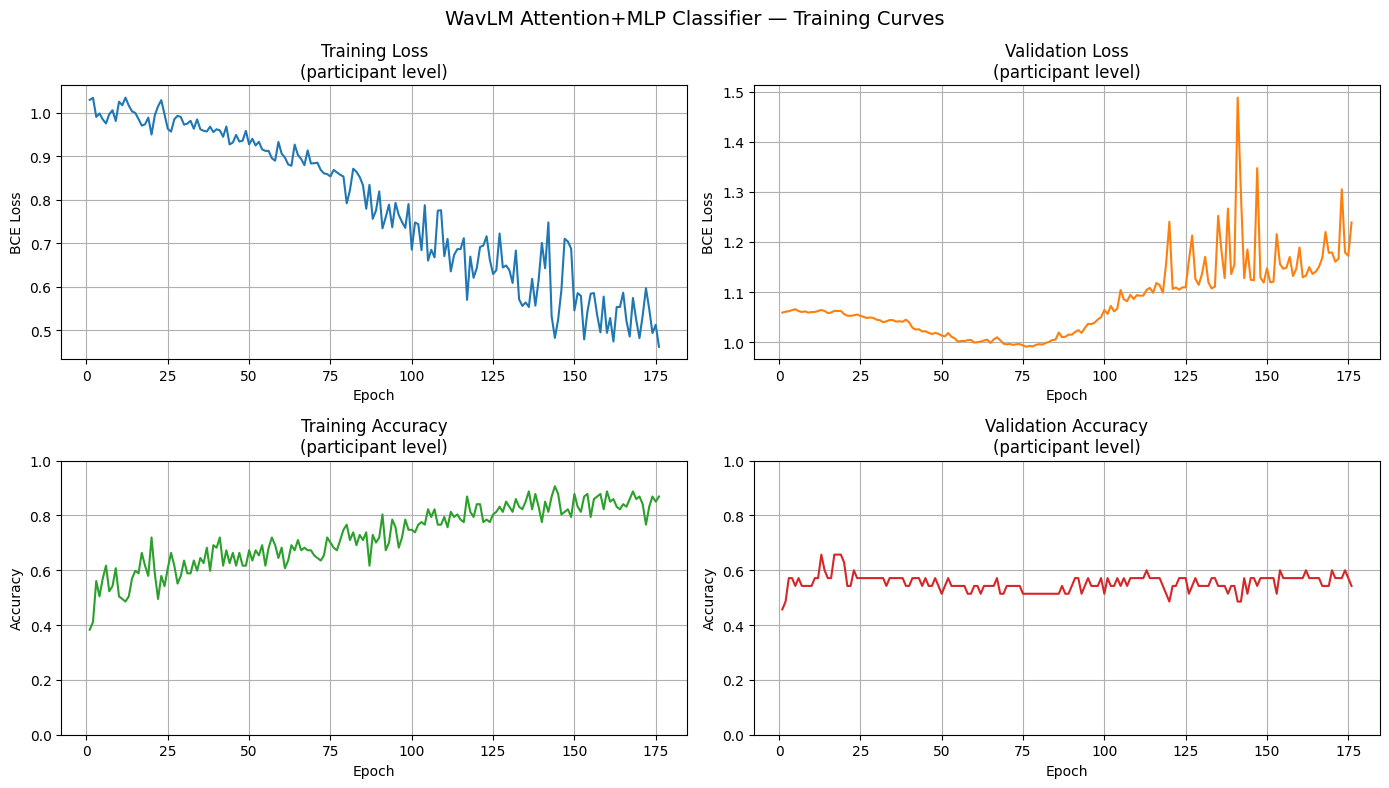

In [10]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("WavLM Attention+MLP Classifier — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Attention Weight Visualisation

Inspect which segments the model attends to for a sample of test participants.
High-weight segments are the ones most influential to the classification decision.

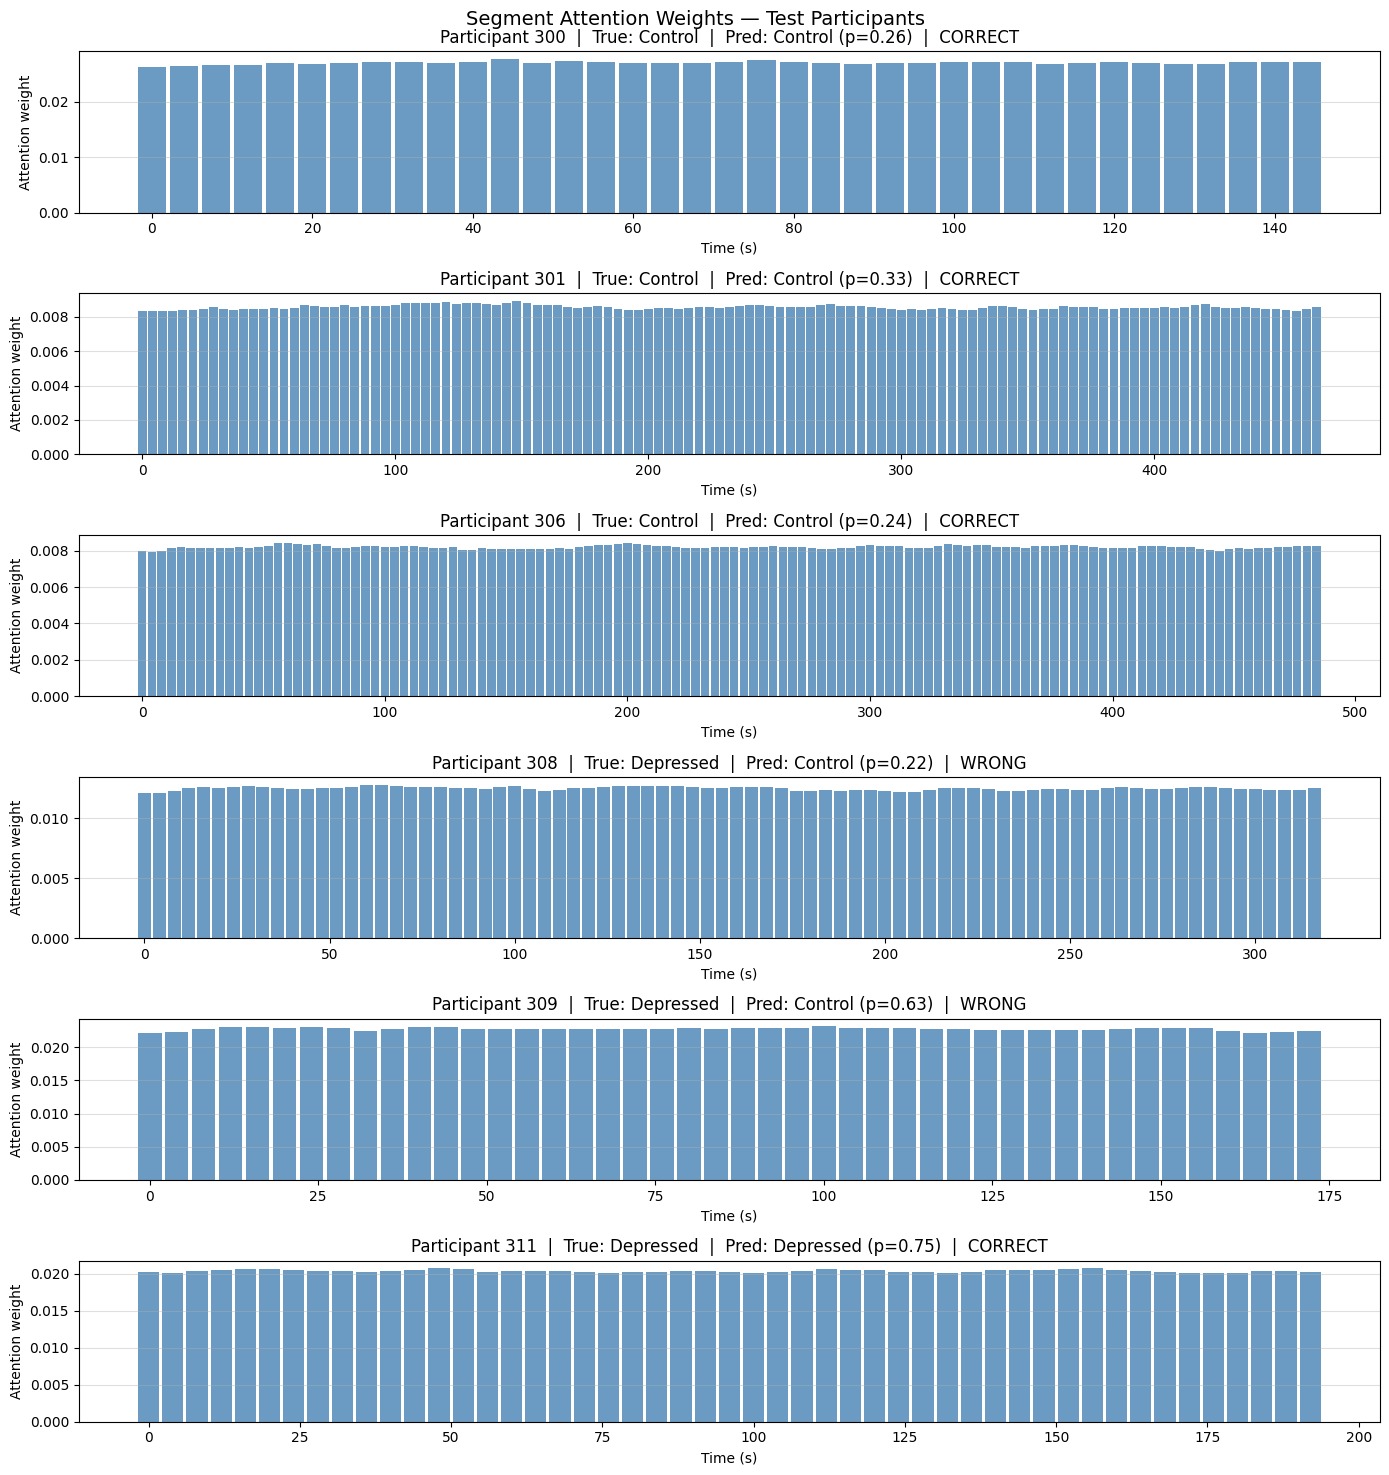

In [11]:
model.eval()
n_show = min(6, len(splits_list["test"]))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show))
if n_show == 1:
    axes = [axes]

with torch.no_grad():
    for ax, (pid, data) in zip(axes, splits_list["test"][:n_show]):
        feats = build_participant_feature_sequence(data, use_augmented_view=False)
        _, attn_weights = model.get_attention_weights(feats)
        attn_weights = attn_weights.squeeze().cpu().numpy()  # (T,)

        logit     = model(feats)
        pred_prob = torch.sigmoid(logit).item()
        pred      = 1 if pred_prob >= best_thresh else 0
        true_lbl  = data["label"]

        time_axis = np.arange(len(attn_weights)) * 4   # 4-second hop
        ax.bar(time_axis, attn_weights, width=3.5, color="steelblue", alpha=0.8)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Attention weight")
        status    = "CORRECT" if pred == true_lbl else "WRONG"
        label_str = "Depressed" if true_lbl == 1 else "Control"
        pred_str  = "Depressed" if pred == 1 else "Control"
        ax.set_title(
            f"Participant {pid}  |  True: {label_str}  |  "
            f"Pred: {pred_str} (p={pred_prob:.2f})  |  {status}"
        )
        ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Segment Attention Weights — Test Participants", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score** using the validation-tuned threshold.

In [12]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("── Test-set results (participant level) ──────────────────")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 76  (val loss 0.9909, val acc 0.5143)
Decision threshold: 0.65  (tuned on validation macro-F1)

Participants evaluated: 47

── Test-set results (participant level) ──────────────────
  Accuracy  : 0.6383  (30/47 correct)
  Precision : 0.3846
  Recall    : 0.3571
  F1 Score  : 0.3704

              precision    recall  f1-score   support

     Control       0.74      0.76      0.75        33
   Depressed       0.38      0.36      0.37        14

    accuracy                           0.64        47
   macro avg       0.56      0.56      0.56        47
weighted avg       0.63      0.64      0.63        47



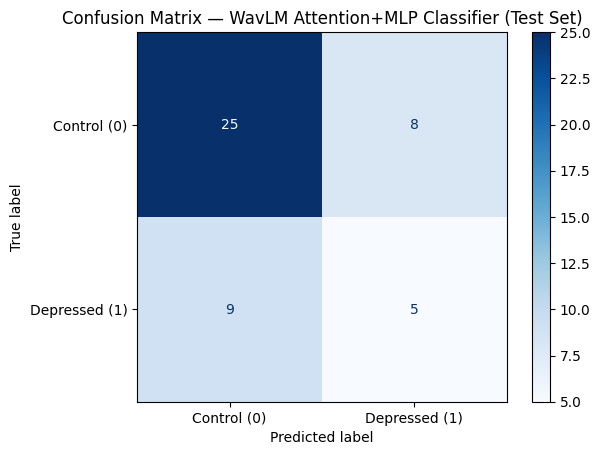

In [13]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — WavLM Attention+MLP Classifier (Test Set)")
plt.show()